# Transfer learning

This notebook demonstrates how you can use transfer learning within Process Optimizer through the use of XpyriMentor 

The point of transfer learning, is to be able to hot-start optimizations by using data from a system that somehow resembles the system of interest.
In case you are wrong, and the new system is in fact significantly different from the prior, you should still be able to complete the optimization and only be slightly worse of compared to starting from a clean slate.

### Install Botorch

The implementation of transfer learning covered here utilizes `botorch`. Runing the below cell will install `botorch`, if you do not already have it. Installing it will take some time and you might have to restart the Python kernel afterwards.

In [2]:
try:
    import botorch
    print("botorch is already installed.")
except Exception:
    print("Installing botorch")
    %pip install botorch
    import botorch
    print("botorch installed successfully.")

botorch is already installed.


In [18]:
import numpy as np

### Specify test systems

First we specify the test systems.

We will use the Hartman 6D system as ground truth in our initial system. The system we transfer to will be a perturbed version of the Hartman 6D system.

In [94]:
from ProcessOptimizer.model_systems import get_model_system

true_system_init = get_model_system('hart6')

true_system_init.set_noise_model("constant")
true_system_init.noise_model.set_noise_type("Gaussian")
true_system_init.noise_size = 0.0

print(true_system_init.get_score([1,1,0,1,1,1]))  # Example call to get the score

-2.8124505439686514e-08


We will also define another system, where we believe that we can transfer learnings between the systems. We do this by loading in a new `hart6` system but then making various pertubations to the input and output. 

In [79]:

true_system_transfer = get_model_system('hart6')

true_system_transfer.set_noise_model("constant")
true_system_transfer.noise_model.set_noise_type("Gaussian")
true_system_transfer.noise_size = 0.1
#true_system_transfer.noise_model.set_noise_type("uniform")
#true_system_transfer.noise_size = 0.2

def score_transfer_system(x, seed=42):
    # Getting some random perturbations and adding them to x
    np.random.seed(seed)
    x_perturbs = np.random.normal(0, 0.2, 6).tolist()
    x = [xi + pi for xi, pi in zip(x, x_perturbs)]

    # Adding some scaling to the system as well
    x_scaling = np.random.normal(1, 0.2, 6).tolist()
    x = [xi*si for xi, si in zip(x, x_scaling )]


    y0 = true_system_transfer.get_score(x)
    # Modify y0 with a linear function
    y = 3.*y0 + 17.

    return y

Let us try it out!

In [80]:
x0 = [0.5, 0.5,1,1,1,1]

print(true_system_init.get_score(x0))
print(score_transfer_system(x0))

0.04020832639599326
17.08118757844016


## Probing the initial system

We start by optimizing within the initial system very much like we would normally do. We perform 20 experiments.

In [112]:
import ProcessOptimizer as po

space = [(0.0, 1.0)]*6
opt = po.Optimizer(dimensions=space, n_initial_points = 20, )
#opt.acq_func_kwargs = {"xi": 0.5}



array([[<Axes: xlabel='$X_{0}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{1}$'>,
        <Axes: xlabel='$X_{1}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{2}$'>, <Axes: >,
        <Axes: xlabel='$X_{2}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{3}$'>, <Axes: >, <Axes: >,
        <Axes: xlabel='$X_{3}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='$X_{4}$'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='$X_{4}$', ylabel='Dependence'>, <Axes: >],
       [<Axes: xlabel='$X_{0}$', ylabel='$X_{5}$'>,
        <Axes: xlabel='$X_{1}$'>, <Axes: xlabel='$X_{2}$'>,
        <Axes: xlabel='$X_{3}$'>, <Axes: xlabel='$X_{4}$'>,
        <Axes: xlabel='$X_{5}$', ylabel='Dependence'>]], dtype=object)

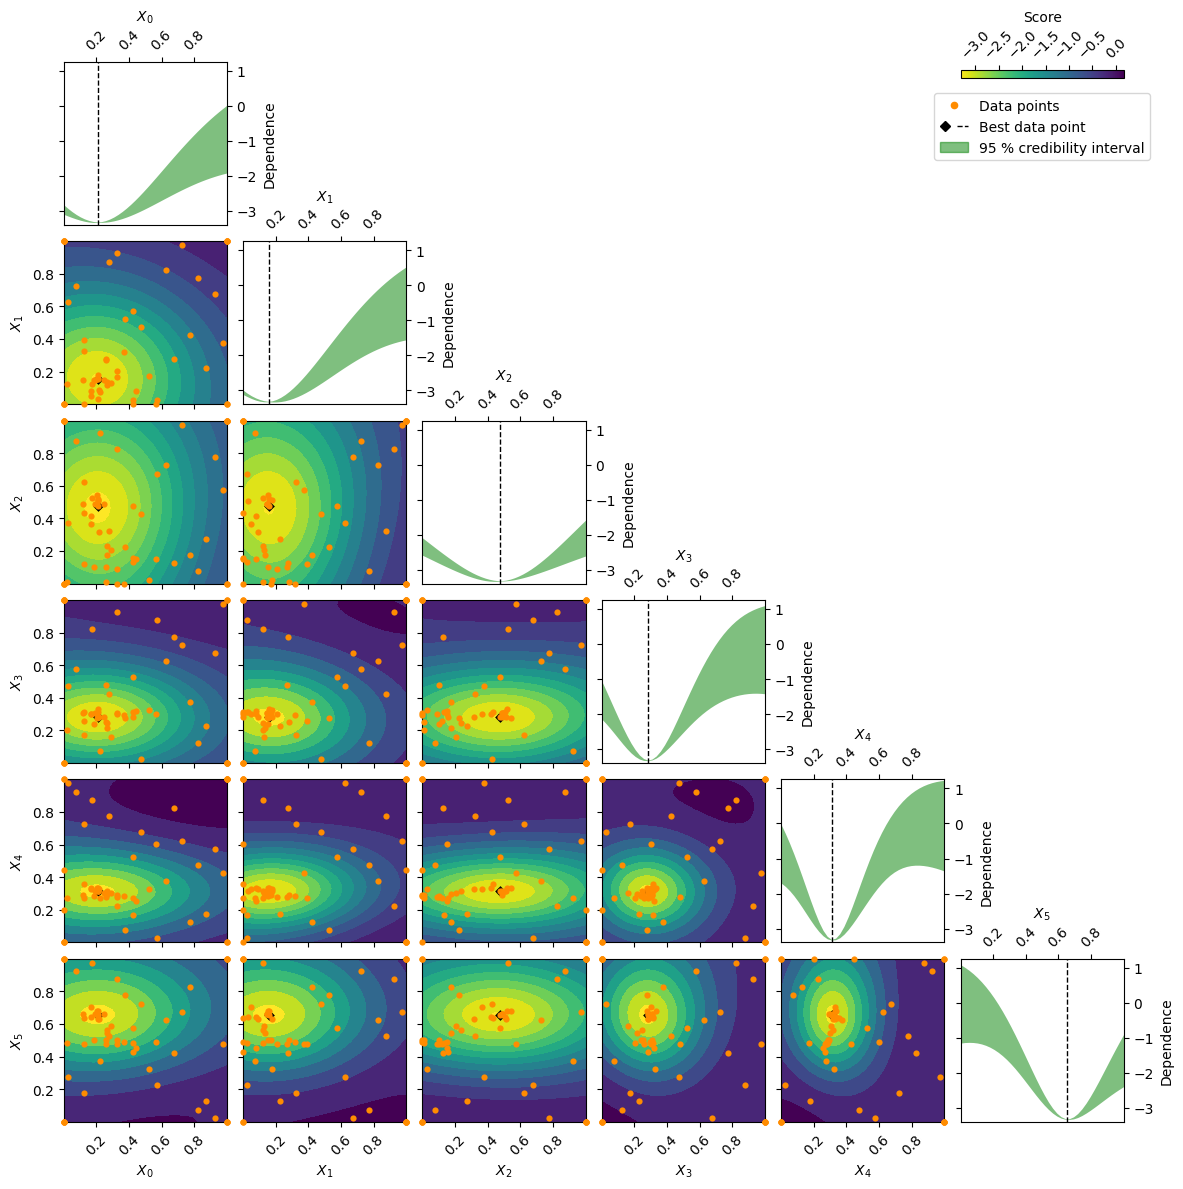

In [ ]:
for _ in range(20):
    xi = opt.ask()
    y = true_system_init.get_score(xi)
    res = opt.tell(xi,y)

po.plot_objective(result=res)

In [25]:
np.random.seed(42)
x_perturbs = np.random.normal(0, 0.2, 6).tolist()
print(x_perturbs)

[0.09934283060224654, -0.027652860234236933, 0.1295377076201385, 0.3046059712816051, -0.046830674944667194, -0.04682739138983611]


We import XpyriMentor and its multitask suggestor

In [3]:
# Necessary functionality from XpyriMentor for TLBO
from ProcessOptimizer import XpyriMentor 
from ProcessOptimizer.XpyriMentor.suggestors import MTSuggestor